---

## The Cuyahoga River - a time series analysis of flooding at the Old Portage streamguage
<a data-flickr-embed="true" href="https://www.flickr.com/photos/jmd41280/7416011986/in/photolist-cijZZC-76YDyp-2obXM49-EGigfp-b1LDBZ-aAscF-KFqCoH-WF6yvu-VRpwMt-2m23pKu-cijTmQ-dZVsW4-bySbP-2rhFH-4Rgtfb-gNzggf-225vRi9-rzP6dB-242ybk4-zpoMZE-2oR6BW4-n2EHaF-2kKHyS3-2pbF53P-5vqDeR-aMcq7B-KFqCez-2oHJnjv-21BFPNA-cpf1A1-awoq8N-vhi56Y-sBoEw-bKaQQR-6FuKCs-awopom-dZVoYz-cn5iBL-cG2FNs-jUAV4W-zDH9zo-2YGL6K-dgfZPM-dgg1pb-agn1qH-72tMZ8-67shbY-2nWDiUJ-5TY9DV-2hxZh51/" title="Cuyahoga River - Peninsula, OH"><img src="https://live.staticflickr.com/8155/7416011986_69a4da3b58_c.jpg" width="800" height="533" alt="Cuyahoga River - Peninsula, OH"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

Image Credit: [Flickr / Jon Dawson](https://www.flickr.com/photos/jmd41280/7416011986/in/photolist-cijZZC-76YDyp-2obXM49-EGigfp-b1LDBZ-aAscF-KFqCoH-WF6yvu-VRpwMt-2m23pKu-cijTmQ-dZVsW4-bySbP-2rhFH-4Rgtfb-gNzggf-225vRi9-rzP6dB-242ybk4-zpoMZE-2oR6BW4-n2EHaF-2kKHyS3-2pbF53P-5vqDeR-aMcq7B-KFqCez-2oHJnjv-21BFPNA-cpf1A1-awoq8N-vhi56Y-sBoEw-bKaQQR-6FuKCs-awopom-dZVoYz-cn5iBL-cG2FNs-jUAV4W-zDH9zo-2YGL6K-dgfZPM-dgg1pb-agn1qH-72tMZ8-67shbY-2nWDiUJ-5TY9DV-2hxZh51/) [CC by ND 2.0](https://creativecommons.org/licenses/by-nd/2.0/)

I grew up on the banks of the Cuyahoga (in Cuyahoga Falls, Ohio) a "crooked river" in the southern Great Lakes region. I don't recall any major flooding while growing up in my hometown of Cuyahoga Falls, but the data record will be better than my memory. 

In [1]:
import os
import subprocess
import urllib
from io import BytesIO

import folium
import hvplot.pandas
import pandas as pd
import requests


### The Cuyahoga River System

![A rendering of the Cuyahoga River system derived from the National Hydrography Dataset and the National Atlas by K. Musser, CC BY-SA 3.0](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Cuyahogarivermap.png/700px-Cuyahogarivermap.png)

Image Source: K. Musser via Wikimedia Commons [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0)

The Cuyhoga River basin covers of 812 miles<sup>2</sup> of northeastern Ohio.<sup>1</sup> This watershed is a mix of urban development, agricultural uses, and forest, including [Cuyahoga Valley National Park](https://www.nps.gov/cuva). The system hosts an array of reservoirs across its upper, middle, and lower sections before draining into Lake Erie in Cleveland. My streamflow analysis will focus on the gauge at [Old Portage, USGS site 04206000](https://waterdata.usgs.gov/nwis/inventory?agency_code=USGS&site_no=04206000) in the Merriman Valley area of Akron, Ohio., in the middle portion of the Cuyahoga. This long-term station has a more extensive data history than other gauges, with daily discharge estimates dating back to 1921. It's important to take note of data availability timelines early on in an analysis project. 

According to the [Climate Toolbox Historical Climograph], 

  * Which **wildlife and ecosystems** exist in the area
  * What **communities and infrastructure** are in the area


### Stream Gauge Map: The Cuyahoga River at Old Portage

In [2]:
#set lat and long
sg_lat = 41.1356112
sg_lon = -81.5470622

# Initialize map and tweak settings
oldportage = folium.Map(
    # Location to display
    location=[sg_lat, sg_lon], zoom_start = 12,
    width=600, height=400,
    # Turns off annoying zooming while trying to scroll to the next cell
    scrollWheelZoom=False,
    tiles='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
     attr=('Map data: &copy; <a href="https://www.openstreetmap.org/copyright"'
           '>OpenStreetMap</a> contributors, <a href="http://viewfinderpanor'
           'amas.org">SRTM</a> | Map style: &copy; <a href="https://opentopo'
           'map.org">OpenTopoMap</a> (<a href="https://creativecommons.org'
           '/licenses/by-sa/3.0/">CC-BY-SA</a>)'))

# Put a marker at the stream gauge location
folium.Marker([sg_lat, sg_lon], popup="Cuyahoga River at Old Portage OH - Site 04206000").add_to(oldportage)

# Display the map
oldportage

#### Data description and citation

The [USGS Water Data for the Nation - National Water Information System (NWIS)](https://waterdata.usgs.gov/nwis?) provides important data on stream characteristics over time for a network of gauges around the U.S. These well-documented daily data provide key streamflow measures including discharge (cubic feet/second); minimum, mean, and maximum water temperature (C); specific conductance (microsiemens per centimeter); and sediment concentration (milligrams per liter). It is available in tab-delimited rdb format via an API. As the network of guages is always changing, data availability varies both temporally and by specific metric. 


In [4]:
import requests
url = ("https://waterdata.usgs.gov/nwis/dv?cb_00060=on&cb_00010=on&cb_80154"
        "=on&cb_80155=on&format=rdb&site_no=04206000&legacy=&referred_module="
        "sw&period=&begin_date=1921-10-01&end_date=2022-12-31")
url
nwis_cfr = requests.get(url)
# Check if the request was successful (status code 200)
#if nwis_cfr.status_code == 200:
#        print(nwis_cfr.text)
#else:
#        print(f"Request failed with status code {nwis_cfr.status_code}")
#nwis_cfr

date_parser = pd.to_datetime
streamdat = pd.read_csv(
    BytesIO(nwis_cfr.content),
    delimiter='\t',
    skiprows=32,
    names=["agency_cd", "site_no", "date", "discharge", "discharge_cd", 
          "susp_sed_conc", "susp_sed_conc_cd", "susp_sed_disch", 
           "susp_sed_disch_cd"],
    parse_dates=True,
    index_col=['date'],
    engine='python'
)
#streamdat

# ---------------------------------- WARNING ----------------------------------------
# Some of the data that you have obtained from this U.S. Geological Survey database
# may not have received Director's approval. Any such data values are qualified
# as provisional and are subject to revision. Provisional data are released on the
# condition that neither the USGS nor the United States Government may be held liable
# for any damages resulting from its use.
#
# Additional info: https://help.waterdata.usgs.gov/policies/provisional-data-statement
#
# File-format description:  https://help.waterdata.usgs.gov/faq/about-tab-delimited-output
# Automated-retrieval info: https://help.waterdata.usgs.gov/faq/automated-retrievals
#
# Contact:   gs-w_waterdata_support@usgs.gov
# retrieved: 2024-02-03 17:39:37 EST       (sdww02)
#
# Data for the following 1 site(s) are contained in this file
#    USGS 04206000 Cuyahoga River at Old Portage OH
# -------------------------------------------------------

## Examining historical mean daily discharge (or streamflow) for the Cuyahoga River

Hydrologic data, data are typically aggregated by the **Water Year**, running from October of the previous year through September of the year of record. The NWIS data record average daily flow (ft<sup>3</sup> second<sup>-1</sup>). Since the data come in daily format, I will first "resample" the data to an annual measure; in other words, aggregate the daily averages to a maximum value per year. 

In [10]:
#streamdat.hvplot.line(y='discharge', ylabel=("Discharge (ft<sup>3</sup> sec"
#                                            "<sup>-1</sup>, thousands)"), 
#                     xlabel='Date', title="Daily Streamflow, 1921 - 2022", 
#                    legend=False, height=500, width=800)annual_max_cr = streamdat[['discharge']].resample("Y").max()
streamdat['dischargen'] = pd.to_numeric(streamdat['discharge']) /1000
#streamdat.info()
annual_max_cr = streamdat[['dischargen']].resample("Y").max()
annual_max_cr.hvplot.line(x='date', y='dischargen', ylabel=
                       "Discharge (cub. ft/sec)", xlabel='Date', 
                       title=("Annual Max. Daily Average Streamflow of the "
                              "Cuyahoga River at Old Portage Gauge, 1921 - "
                              "2022"), 
                       legend=False, height=500, width=800)

/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Curve   [date]   (dischargen)

I'm interested in the high water events that are grouped together in the early 2000s. In July 2003, May 2004, and January 2005, there were very high flows. Let's look at the highest of the three, in 2004. Another way to look at streamflow history is to plot the absolute maximum flow rate per year, rather than plotting the maximum of the daily averages, though a long time series like this will probably not look too different. Instantaneous flow data also come from the NWIS and can be pulled with the API. 

In [15]:
# download usgs annual max data 
url2 = ("https://nwis.waterdata.usgs.gov/nwis/peak?site_no=04206000&agency_cd="
        "USGS&format=rdb")
usgs_peak_cr = requests.get(url2)
#download_path = os.path.join("streamdat", "streamdat2019")
#urllib.request.urlretrieve(url, download_path)
usgs_peak_cr
cr_peakflow = pd.read_csv(
    BytesIO(usgs_peak_cr.content),
    delimiter='\t',
    skiprows=74,
    names=["agency_cd", "site_no", "peak_dt", "peak_tm", "peak_va", "peak_cd", 
           "gage_ht", "gage_ht_cd", "year_last_pk", "ag_dt", "ag_tm", 
           "ag_gage_ht", "ag_gage_ht_cd" ],
    parse_dates=True,
    index_col=['peak_dt'],
    engine='python'
)
cr_peakflow.hvplot.line(x='peak_dt', y='peak_va', ylabel=
                       "Discharge (cub. ft/sec)", xlabel='Date', 
                       title=("Annual Maximum Daily Streamflow of the "
                              "Cuyahoga River at Old Portage Gauge, 1921 - "
                              "2022"), 
                       legend=False, height=500, width=800)

/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Curve   [peak_dt]   (peak_va)

In [12]:
# Subset data to 1959
#streamdat1959 = streamdat.loc['1959-01-01':'1959-12-31']
#streamdat1959
#streamdat1959.hvplot.line(y='discharge', ylabel="Discharge (cub. ft/sec)", xlabel='Date', 
#                       title="Daily Streamflow of the Cuyahoga River at Old Portage, 1959", legend=False, height=500, width=620)

Now, I will look closer at the high discharge event(s) in 2004. 

In [17]:
# Subset data to 2004
streamdat04 = streamdat.loc['2004-01-01':'2004-12-31']
streamdat04
streamdat04.hvplot.line(y='discharge', ylabel="Discharge (cub. ft/sec)", 
                        xlabel='Date', legend=False, height=500, width=620,
                        title=("Daily Streamflow of the Cuyahoga River at Old "
                               "Portage, 2004"))

/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Curve   [date]   (discharge)

Looking at the daily average streamflow measures for 2004 we can see more precisely when the event occurred and how the May 2004 flood compared to other times of high water that year. The peak, 4,870 feet<sup>3</sup> second<sup>-1</sup> occurred on May 22, 2004. I did some internet research into the weather events surrounding this high water event. 


<additional info here>



/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/opt/conda/lib/python3.10/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Curve   [date]   (discharge)

### > A **time series** of data is taken at the same location but collected regularly or semi-regularly over time. 

You will then consider how the values compared to previous years before the flood event by computing the flood's **return period**.

> A **return period** is an estimate of how often you might expect to see a flood of at least a particular size. This does *NOT* mean an extreme flood "has" to occur within the return period, or that it couldn't occur more than once.

To complete this analysis, I need repeated measures of flow at the station of interest. These measurements should have been conducted in a standardized way each time using the same or comparable instruments. This helps make the time series data more reliable for purposes of trend estimation and return periods. A decade is needed at a minimum for calculating return period, but several decades is better. 

&#128214; Resources that I used from the Earth Lab's Earth Data Science textbook include the following:
  * [Introduction to time-series data](https://www.earthdatascience.org/courses/use-data-open-source-python/use-time-series-data-in-python/)
  * [Flood return period and probability](https://www.earthdatascience.org/courses/use-data-open-source-python/use-time-series-data-in-python/floods-return-period-and-probability/)
  

### High Streamflow Intervals for the Cuyahoga River at Old Portage

The current streamflow time series covers a period of 102 years. During this period, there was just 1 year in which maximum streamflow exceeded 6,000 cubic feet per second. Therefore, we can estimate such a streamflow level as a 1-in-x or a roughly 1-in-x year likelihood of occuring. It is probably reasonable to say a flow of x,000 cfs or greater has a 20-year return interval.

# Flood Return Period 

&#127798; EXTRA CHALLENGE In the cell below, calculate the exceedence probability and return period for each year of the **annual** data, and add them as columns to your DataFrame. To pass the tests, subset data after 1953, when there was a regime change evident on the river. What do you think caused that?.

In [34]:
import hydrofunctions as hf
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# download usgs annual max data 
url2 = ("https://nwis.waterdata.usgs.gov/nwis/peak?site_no=04206000&agency_cd="
        "USGS&format=rdb")
usgs_peak_crop = requests.get(url2)
#download_path = os.path.join("streamdat", "streamdat2019")
#urllib.request.urlretrieve(url, download_path)
usgs_peak_crop
crop_peakflow = pd.read_csv(
    BytesIO(usgs_peak_crop.content),
    delimiter='\t',
    skiprows=74,
    names=["agency_cd", "site_no", "peak_dt", "peak_tm", "peak_va", "peak_cd", 
           "gage_ht", "gage_ht_cd", "year_last_pk", "ag_dt", "ag_tm", 
           "ag_gage_ht", "ag_gage_ht_cd" ],
    parse_dates=True,
    index_col=['peak_dt'],
    engine='python'
)
crop_peakflow

,agency_cd,site_no,peak_tm,peak_va,peak_cd,gage_ht,gage_ht_cd,year_last_pk,ag_dt,ag_tm,ag_gage_ht,ag_gage_ht_cd
peak_dt,,,,,,,,,,,,
1922-03-31,USGS,4206000,NaN,2130,5,7.20,NaN,NaN,NaN,NaN,NaN,NaN
1923-01-21,USGS,4206000,NaN,1840,5,6.60,NaN,NaN,NaN,NaN,NaN,NaN
1924-06-28,USGS,4206000,NaN,4450,5,10.80,NaN,NaN,NaN,NaN,NaN,NaN
1925-02-12,USGS,4206000,NaN,2200,5,7.40,NaN,NaN,NaN,NaN,NaN,NaN
1926-09-06,USGS,4206000,NaN,2820,5,8.30,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-06-17,USGS,4206000,09:00,5030,5,11.97,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-07,USGS,4206000,16:30,4220,5,10.41,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-09,USGS,4206000,17:30,3820,5,9.71,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Sort data smallest to largest
crop_peakflow["year"] = crop_peakflow.index.year
inpeak_sort = crop_peakflow.sort_values(by="peak_va")

# Count total obervations
n = inpeak_sort.shape[0]

# Add a numbered column 1 -> n to use in return calculation for rank
inpeak_sort.insert(0, 'rank', range(1, 1 + n))

# Calculate probability - note you may need to adjust this value based upon the time period of your data
inpeak_sort["probability"] = (
    (n - inpeak_sort["rank"] + 1) / (n + 1))
inpeak_sort["return-years"] = (
    1 / inpeak_sort["probability"])

In [36]:
inpeak_sort[['year', 'peak_va', 'rank', 'probability', 'return-years']]

,year,peak_va,rank,probability,return-years
peak_dt,,,,,
1931-09-16,1931,1300,1,0.990099,1.010000
1932-01-23,1932,1720,2,0.980198,1.020202
1923-01-21,1923,1840,3,0.970297,1.030612
1962-02-27,1962,1890,4,0.960396,1.041237
1954-04-27,1954,2000,5,0.950495,1.052083
...,...,...,...,...,...
2014-05-13,2014,5500,96,0.049505,20.200000
2004-05-22,2004,5570,97,0.039604,25.250000
1979-09-14,1979,6230,98,0.029703,33.666667


In [48]:
annual_max_cr = annual_max_cr[annual_max_cr.index.year >= 1922]
annual_max_cr['peak_va'] = annual_max_cr['discharge'] 
#now calculate the return period using the resampled annual max data, but subset to same period

# Sort data smallest to largest
annual_max_cr_sort = annual_max_cr.sort_values(by="discharge")
annual_max_cr_sort["year"] = annual_max_cr.index.year
# Count total obervations
n = annual_max_cr_sort.shape[0]# Add a numbered column 1 -> n to use in return calculation for rank
annual_max_cr_sort.insert(0, 'rank', range(1, 1 + n))

# Calculate probability - note you may need to adjust this value based upon the time period of your data
annual_max_cr_sort["probability"] = (
    (n - annual_max_cr_sort["rank"] + 1) / (n + 1))
annual_max_cr_sort["return-years"] = (
    1 / annual_max_cr_sort["probability"])

/tmp/ipykernel_9407/174072097.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annual_max_cr['peak_va'] = annual_max_cr['discharge']


In [49]:
annual_max_cr_sort[['year', 'peak_va', 'rank', 'probability', 'return-years']]

,year,peak_va,rank,probability,return-years
date,,,,,
1953-12-31,1922,1040.0,1,0.990196,1.009901
1931-12-31,1923,1140.0,2,0.980392,1.020000
1988-12-31,1924,1550.0,3,0.970588,1.030303
1941-12-31,1925,1560.0,4,0.960784,1.040816
1962-12-31,1926,1570.0,5,0.950980,1.051546
...,...,...,...,...,...
1979-12-31,2018,5040.0,97,0.049020,20.400000
1959-12-31,2019,6040.0,98,0.039216,25.500000
1936-12-31,2020,NaN,99,0.029412,34.000000


In [42]:
import matplotlib.pyplot as plt
%matplotlib inline

/tmp/ipykernel_9407/2687817050.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0.0, top=1.0)


Text(0.5, 1.0, 'Probability of Discharge Events \n USGS NWIS Annual Maximum Daily Mean Data, Cuyahoga River at Old Portage Gauge, 1922 - 2022')

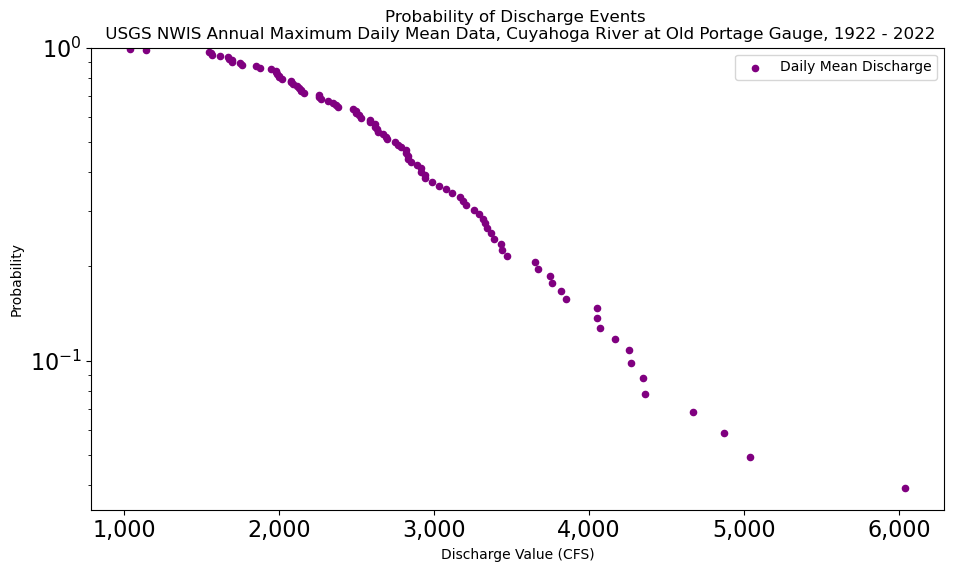

In [50]:
fig, ax = plt.subplots(figsize=(11, 6))
annual_max_cr_sort.plot.scatter(y="probability",
                           x="peak_va",
                           title="Probability ",
                           ax=ax,
                           color='purple',
                           fontsize=16,
                           logy=True,
                           label="Daily Mean Discharge")

ax.get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.ylim(bottom=0.0, top=1.0)
ax.set_ylabel("Probability")
ax.set_xlabel("Discharge Value (CFS)")
ax.set_title(("Probability of Discharge Events \n USGS NWIS Annual Maximum "
             "Daily Mean Data, Cuyahoga River at Old Portage Gauge, 1922 - 2022"))


In [45]:
plt.show()

/tmp/ipykernel_9407/785443141.py:23: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0.0, top=1.0)


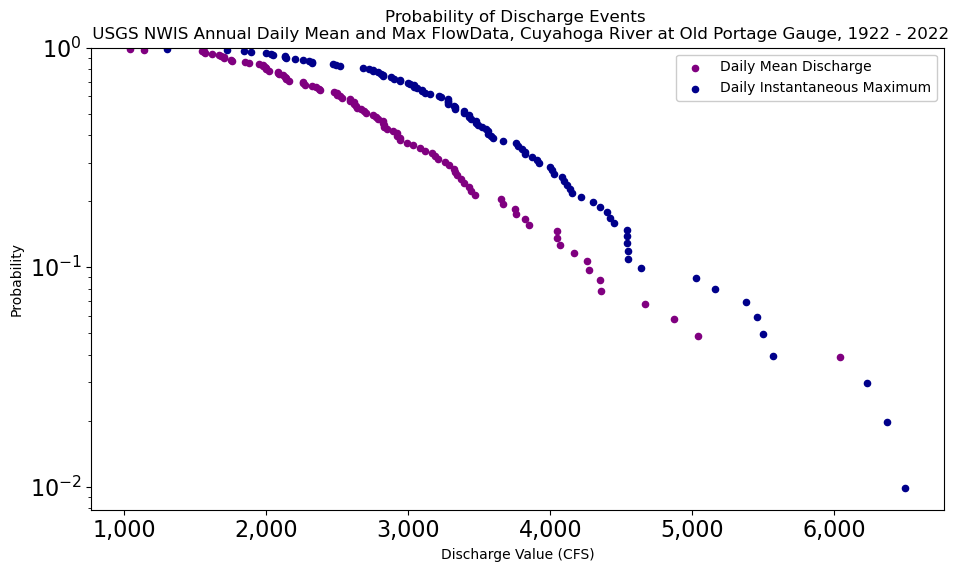

In [43]:
fig, ax = plt.subplots(figsize=(11, 6))
annual_max_cr_sort.plot.scatter(y="probability",
                           x="peak_va",
                           title="Probability ",
                           ax=ax,
                           color='purple',
                           fontsize=16,
                           logy=True,
                           label="Daily Mean Discharge")

inpeak_sort.plot.scatter(y="probability",
                           x="peak_va",
                           title="Probability ",
                           ax=ax,
                           color='darkblue',
                           fontsize=16,
                           logy=True,
                           label="Daily Instantaneous Maximum")
ax.legend(frameon=True,
          framealpha=1)
ax.get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.ylim(bottom=0.0, top=1.0)
ax.set_ylabel("Probability")
ax.set_xlabel("Discharge Value (CFS)")
ax.set_title(("Probability of Discharge Events \n USGS NWIS Annual Daily Mean and Max Flow"
             "Data, Cuyahoga River at Old Portage Gauge, 1922 - 2022"))

plt.show()